# 6D-VHQ Analysis Notebook 1 : Face Validity with images

## File setup

todos

- dimension names and labels are generated and re-generated a number of times, make one standard variable for this
- move all imports to the top section and remove redundancies
- try removing old unused figure blocks
- name figure in code

In [ ]:
## import libraries

import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from PIL import Image
import statsmodels.formula.api as smf
from scipy.stats import gaussian_kde

In [ ]:
### set up filepaths

project_path =  Path().resolve().parent 
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")
imgs_path = os.path.join(project_path, "imgs")


In [18]:
### question key for the 6D-VHQ
### these "question key" files determine which items belong to which dimension, which are reverse coded, etc

# get and read excel file
vhq_key_path = os.path.join(qKeys_path, "VHQ_question_key.xlsx")
question_key = pd.read_excel(vhq_key_path)
question_key['q_col']   = question_key['question'].apply(lambda n: f"Q{n}")

rev_list = question_key["reversed"].to_list()

print(question_key.head())

   question  dimension  reversed  expected       name  \
0         1          1         0        -1  geometric   
1         2          1         0        -1  geometric   
2         3          1         0        -1  geometric   
3         4          2         0        -1   semantic   
4         5          2         0        -1   semantic   

                                            text_old  \
0  I saw shapes, lines, dots, or other geometric ...   
1  I saw geometrical patterns, similar to honeyco...   
2  I saw patterns, such as repeating shapes or co...   
3  I saw things which looked like living beings, ...   
4  My visual experience contained elements that r...   

                                                text q_col  
0  1. I saw shapes, lines, dots, or other geometr...    Q1  
1  2. I saw geometrical patterns, similar to hone...    Q2  
2  3. I saw patterns, such as repeating shapes or...    Q3  
3  4. I saw things which looked like living being...    Q4  
4  5. My visual

In [19]:
### Dimension names ###

### with infrequency dimension
dimension_names = list(dict.fromkeys(question_key["name"]))
 
## without infrequency dimension
dimension_labels = dimension_names[:-1]

## dimensional data import

This file examines face validity with dimension values, not requiring item-level data

We only examine data from image trials from Experiment 1 and 2

In [20]:
## import dimension data from Experiments 1 and 2

df_vhq_img_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_img_dims.csv"))
df_vhq_lab_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_lab_dims.csv"))

display(df_vhq_img_dims)
display(df_vhq_lab_dims)

,trial_ids,image_number,geometric,semantic,detail,vividness,entropy,focality,infrequency
0,0,10,2.333333,3.666667,1.000000,2.000000,1.000000,4.333333,1.666667
1,1,3,3.333333,4.000000,4.000000,2.333333,3.333333,1.333333,1.666667
2,2,6,1.000000,3.333333,1.000000,1.000000,1.000000,4.666667,1.666667
3,3,7,1.000000,1.666667,1.000000,4.333333,1.000000,1.000000,1.666667
4,4,8,4.000000,1.333333,3.000000,5.000000,2.666667,3.333333,1.666667
...,...,...,...,...,...,...,...,...,...
195,210,10,1.000000,5.000000,1.000000,2.333333,1.333333,1.666667,1.666667
196,211,5,4.666667,1.333333,1.333333,4.000000,1.000000,1.333333,1.666667
197,212,2,5.000000,3.333333,2.333333,2.666667,2.000000,1.666667,1.666667
198,213,4,1.000000,1.000000,1.000000,2.000000,3.333333,4.333333,1.666667


,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality
0,participant_001,0,1,53BA74C6021,2.000000,1.000000,1.666667,5.000000,1.000000,4.333333
1,participant_001,1,1,53BA74C6021,2.333333,1.000000,1.000000,4.000000,1.333333,5.000000
2,participant_001,2,1,53BA74C6021,2.000000,1.000000,1.000000,5.000000,1.333333,5.000000
3,participant_001,3,1,53BA74C6021,4.000000,1.333333,2.333333,3.666667,3.333333,5.000000
4,participant_001,4,1,53BA74C6021,5.000000,2.000000,4.666667,5.000000,2.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...
600,participant_055,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333
601,participant_055,7,3,253C671BA04,1.000000,1.333333,1.000000,2.666667,1.666667,1.000000
602,participant_055,A,3,253C671BA04,4.333333,2.333333,4.000000,4.000000,3.666667,1.666667
603,participant_055,B,3,253C671BA04,5.000000,1.000000,2.666667,3.666667,1.000000,2.666667


## Spider Plots

In [ ]:

# --- CONFIGURATION ---

n_dims = len(dimension_labels)
angles = np.linspace(0, 2*np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]


### Figure S1

C:\Users\Trevor\AppData\Local\Temp\ipykernel_18696\486947026.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


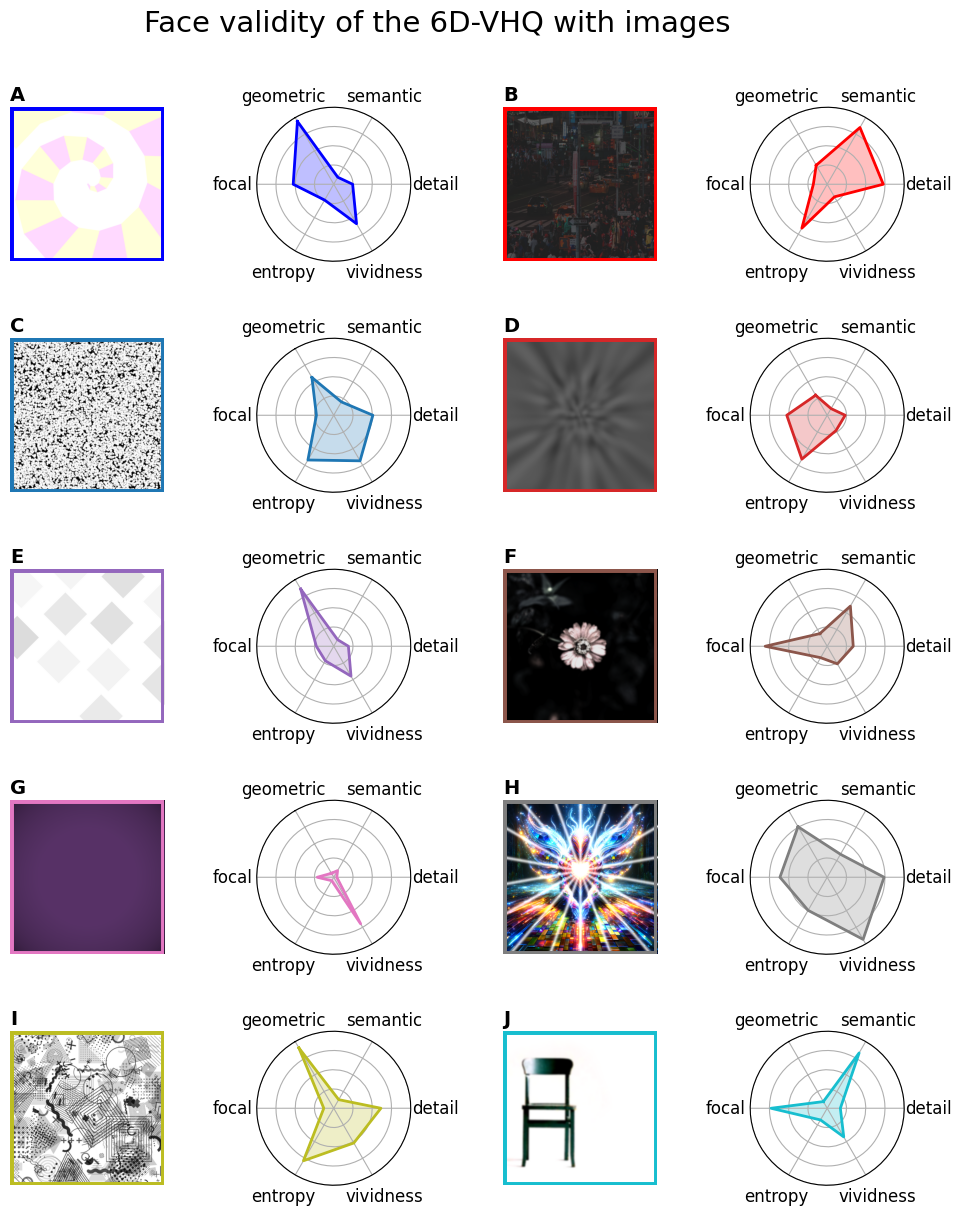

In [22]:

# --- Configuration variables ---
text_size    = 14   # base text size
lw_line      = 2    # width of spider lines
alpha_fill   = 0.25 # fill transparency
lw_outline   = 5    # width of image borders
fig_width    = 12   # overall figure width
fig_height   = 14   # overall figure height
spider_rot   = np.deg2rad(30.01)  # rotation in radians

# --- Override colors: Tab10 but force image2=blue, image3=red ---
cmap   = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(10)]
colors[1] = 'blue'  # image_number=2
colors[2] = 'red'   # image_number=3

# prepare dimension labels for the spider (rename "focality" → "focal")
dims_labels = ['focal' if d == 'focality' else d for d in dimension_labels]



# --- display order & letter labels ---
display_order = [2, 3, 1, 4, 5, 6, 7, 8, 9, 10]  # 02→A, 03→B, 01→C, then 04..10
letters       = list("ABCDEFGHIJ")               # A..J


# --- Create figure ---
fig = plt.figure(figsize=(fig_width, fig_height))
# 5 rows, 4 columns: [image, spider, image, spider]
gs = GridSpec(5, 4, figure=fig, width_ratios=[1, 0.9, 1, 0.9],
              wspace=0.3, hspace=0.5)

for row in range(5):
    # Indices into the display order
    idx_left  = row            # 0..4  (A, C, E, G, I positions if laid row-wise)
    idx_right = row + 5        # 5..9  (F, H, J, ... row-wise second column)

    # LEFT column images (1–5)
    # img_num_left = row + 1
    # fname_left   = f"img_{img_num_left:02d}.png"
    pos_left      = 2*row
    img_num_left  = display_order[pos_left]
    fname_left    = f"img_{img_num_left:02d}.png"
    ax_img_left  = fig.add_subplot(gs[row, 0])
    img_left     = Image.open(os.path.join(imgs_path, fname_left))
    ax_img_left.imshow(img_left)
    ax_img_left.axis('off')
    # outline in image-specific color
    rect = Rectangle((0, 0), 1, 1, transform=ax_img_left.transAxes,
                     fill=False, edgecolor=colors[img_num_left - 1], linewidth=lw_outline)
    ax_img_left.add_patch(rect)
    ax_img_left.text(0.0, 1.02, letters[pos_left], transform=ax_img_left.transAxes,
                    ha='left', va='bottom', fontsize=text_size, fontweight='bold')

    # --- LEFT column: spider for this image ---
    ax_spider_left = fig.add_subplot(gs[row, 1], polar=True)
    sub_left   = df_vhq_img_dims[df_vhq_img_dims['image_number'] == img_num_left]
    left_means = sub_left[dimension_labels].mean().tolist()
    left_means = left_means + left_means[:1]  # close the loop

    ax_spider_left.set_theta_offset(np.pi/2 + spider_rot)
    ax_spider_left.set_theta_direction(-1)
    ax_spider_left.set_thetagrids(np.degrees(angles[:-1]), labels=dims_labels, fontsize=text_size-2)
    ax_spider_left.set_ylim(1, 5)
    ax_spider_left.set_yticklabels([])
    ax_spider_left.tick_params(axis='x', pad=7)
    ax_spider_left.plot(angles, left_means, color=colors[img_num_left - 1], linewidth=lw_line)
    ax_spider_left.fill(angles, left_means, color=colors[img_num_left - 1], alpha=alpha_fill)

    # RIGHT column images (6–10)
    # img_num_right = row + 6
    # fname_right   = f"img_{img_num_right:02d}.png"
    pos_right      = 2*row + 1
    img_num_right  = display_order[pos_right]
    fname_right    = f"img_{img_num_right:02d}.png"
    ax_img_right  = fig.add_subplot(gs[row, 2])
    img_right     = Image.open(os.path.join(imgs_path, fname_right))
    ax_img_right.imshow(img_right)
    ax_img_right.axis('off')
    rect = Rectangle((0, 0), 1, 1, transform=ax_img_right.transAxes,
                     fill=False, edgecolor=colors[img_num_right - 1], linewidth=lw_outline)
    ax_img_right.add_patch(rect)
    ax_img_right.text(0.0, 1.02, letters[pos_right], transform=ax_img_right.transAxes,
                    ha='left', va='bottom', fontsize=text_size, fontweight='bold')

    # --- RIGHT column: spider for this image ---
    ax_spider_right = fig.add_subplot(gs[row, 3], polar=True)
    sub_right   = df_vhq_img_dims[df_vhq_img_dims['image_number'] == img_num_right]
    right_means = sub_right[dimension_labels].mean().tolist()
    right_means = right_means + right_means[:1]

    ax_spider_right.set_theta_offset(np.pi/2 + spider_rot)
    ax_spider_right.set_theta_direction(-1)
    ax_spider_right.set_thetagrids(np.degrees(angles[:-1]), labels=dims_labels, fontsize=text_size-2)
    ax_spider_right.set_ylim(1, 5)
    ax_spider_right.set_yticklabels([])
    ax_spider_right.tick_params(axis='x', pad=7)
    ax_spider_right.plot(angles, right_means, color=colors[img_num_right - 1], linewidth=lw_line)
    ax_spider_right.fill(angles, right_means, color=colors[img_num_right - 1], alpha=alpha_fill)

fig.suptitle("Face validity of the 6D-VHQ with images", fontsize=text_size * 1.5, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### FIGURE 1

In [23]:
# --- Select the n most different images via greedy max–min ---

n = 4
feat = np.vstack([
    df_vhq_img_dims[df_vhq_img_dims['image_number'] == i][dimension_labels].mean().values
    for i in range(1, 11)
])

alpha_fill = 0.0

from scipy.spatial.distance import pdist, squareform
D = squareform(pdist(feat, metric='euclidean'))

i, j = divmod(D.argmax(), D.shape[1])
selected = [i, j]

while len(selected) < n:
    mins = [
        (idx, min(D[idx, sel] for sel in selected))
        for idx in range(10) if idx not in selected
    ]
    next_idx, _ = max(mins, key=lambda x: x[1])
    selected.append(next_idx)

# image numbers 1..10
selected_imgs = [idx + 1 for idx in selected]

# mean vectors (closed loop)
mean_vectors = {}
for img_num in selected_imgs:
    sub = df_vhq_img_dims[df_vhq_img_dims['image_number'] == img_num]
    m = sub[dimension_labels].mean().tolist()
    mean_vectors[img_num] = m + [m[0]]
# --- naming inherited from the first block ---
display_order    = [2, 3, 1, 4, 5, 6, 7, 8, 9, 10]
letters          = list("ABCDEFGHIJ")
image_to_letter  = {img: letters[i] for i, img in enumerate(display_order)}


Plot 1 mapping (online experiment, selected images):
  Image I: original image_number=9
  Image J: original image_number=10
  Image B: original image_number=3
  Image G: original image_number=7


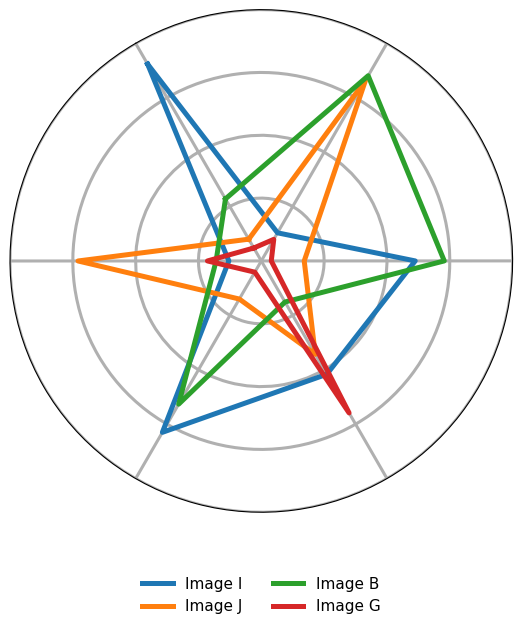

In [ ]:
# ============================================
#  radar plots for face-validity figures
# ============================================

# Dimensions & angles
n_dims = len(dimension_labels)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]

# Radial ticks (gridlines only, no labels)
radial_ticks = [1, 2, 3, 4, 5]

# --------------------------------------------
# Helper: create a radar figure with fixed style
# --------------------------------------------
def make_radar_figure(profiles, labels, colors, legend_ncol=2):
    fig = plt.figure(figsize=(fig_width, fig_height / 2))
    ax  = fig.add_subplot(111, polar=True)

    # Rotation and direction
    ax.set_theta_offset(np.pi/2 + spider_rot)
    ax.set_theta_direction(-1)

    # Remove dimension labels entirely
    ax.set_thetagrids(
        np.degrees(angles[:-1]),
        labels=[]
    )

    # Radial axis: 1–5 gridlines; no labels
    ax.set_ylim(1, 5)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([])

    # Thicker gridlines everywhere
    ax.grid(True)
    for gridline in ax.xaxis.get_gridlines():
        gridline.set_linewidth(2.2)
    for gridline in ax.yaxis.get_gridlines():
        gridline.set_linewidth(2.2)

    # Plot each profile
    for prof, lbl, col in zip(profiles, labels, colors):
        vals = prof.tolist() if hasattr(prof, "tolist") else list(prof)
        vals = vals + vals[:1]
        ax.plot(angles, vals, color=col, linewidth=lw_line * 1.8, label=lbl)
        ax.fill(angles, vals, color=col, alpha=alpha_fill)

    # No title
    ax.set_title("")

    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
              ncol=legend_ncol, frameon=False, fontsize=text_size - 3)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    return fig, ax

# -------------------------------------------------
# Plotting selected images from the online experiment
# -------------------------------------------------

plot1_profiles = []
plot1_labels   = []

for img_num in selected_imgs:
    full_vec = mean_vectors[img_num]
    base_vec = full_vec[:-1]
    plot1_profiles.append(base_vec)
    plot1_labels.append(f"Image {image_to_letter[img_num]}")

plot1_colors = [plt.get_cmap('tab10')(i) for i in range(len(plot1_profiles))]

print("Plot 1 mapping (online experiment, selected images):")
for lbl, img_num in zip(plot1_labels, selected_imgs):
    print(f"  {lbl}: original image_number={img_num}")

fig1, ax1 = make_radar_figure(
    profiles = plot1_profiles,
    labels   = plot1_labels,
    colors   = plot1_colors,
    legend_ncol=2
)



## Figure 5

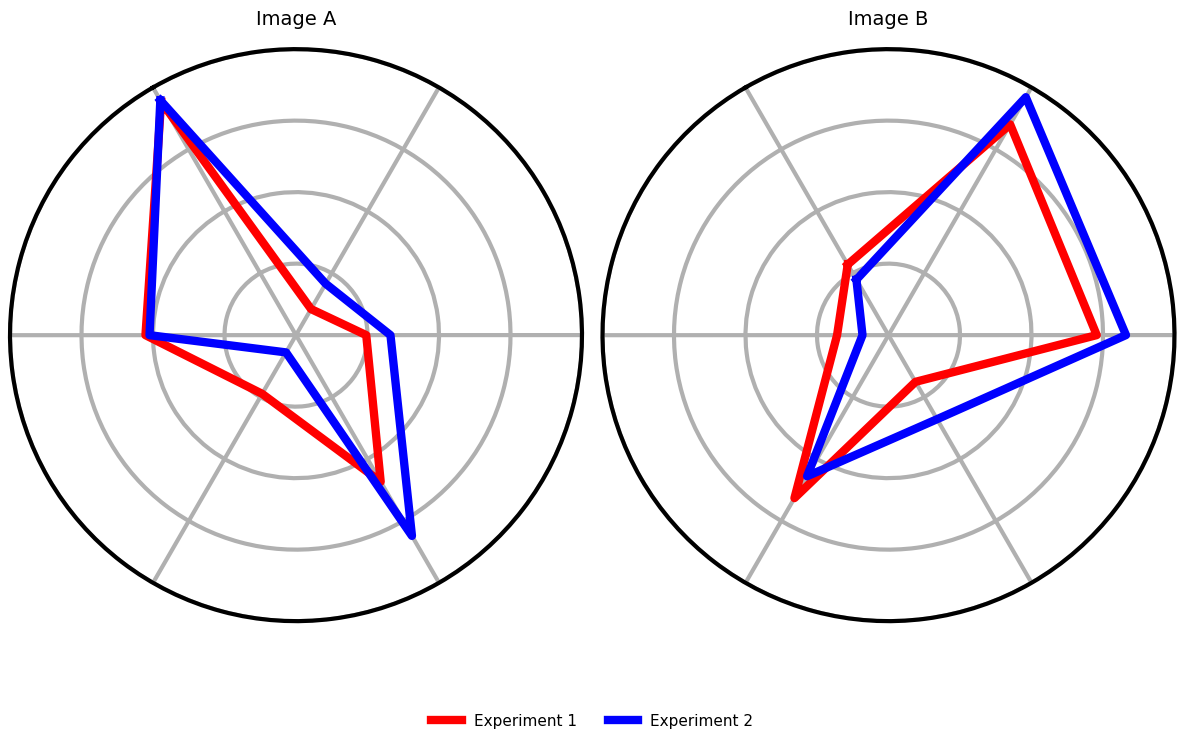

In [ ]:

# name experiment columns
df_vhq_img_dims['experiment'] = 'img'
df_vhq_lab_dims['experiment'] = 'lab'

# keep only conditions B→2, C→3
cond_to_img = {'B': 2, 'C': 3}
df_vhq_lab_dims = df_vhq_lab_dims[
    df_vhq_lab_dims['condition'].isin(cond_to_img)
].copy()
df_vhq_lab_dims['image_number'] = df_vhq_lab_dims['condition'].map(cond_to_img)

# combine
combined = pd.concat([df_vhq_img_dims, df_vhq_lab_dims], ignore_index=True)


# --- PARAMETERS FOR ALL RADAR PLOTS ---
labelpad     = 20          # how far out the dimension labels sit
rotation_deg = -330         # rotate entire chart by this many degrees

# Dimensions & angles
dims   = ['geometric','semantic','detail','vividness','entropy','focality']
angles = np.linspace(0, 2*np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]


# --- HELPER TO PLOT MULTI-LINE RADAR ---
def radar_plot(profiles, labels, colors, title, legend_title=None):
    # make figure wide
    fig = plt.figure(figsize=(10,5))
    # put the radar in the left half: [left, bottom, width, height]
    ax  = fig.add_axes([0.05, 0.1, 0.5, 0.8], polar=True)

    # 1) apply rotation
    theta_off = np.pi/2 + np.deg2rad(rotation_deg)
    ax.set_theta_offset(theta_off)
    ax.set_theta_direction(-1)

    # 2) set dimension labels + padding
    ax.set_thetagrids(np.degrees(angles[:-1]), labels=dims)
    ax.tick_params(axis='x', pad=labelpad)

    # 3) radial axis: whole-number ticks, no labels
    ax.set_yticks([1,2,3,4,5])
    ax.set_yticklabels([])
    ax.set_ylim(1,5)

    # 4) plot each profile
    for prof, lbl, col in zip(profiles, labels, colors):
        vals = prof.tolist() + prof.tolist()[:1]
        ax.plot(angles, vals, label=lbl, color=col, linewidth=2)
        ax.fill(angles, vals, color=col, alpha=0.0)

    # 5) title + legend on the right half
    ax.set_title(title, y=1.1)
    if legend_title:
        ax.legend(title=legend_title, loc='upper left',
                  bbox_to_anchor=(1.05, 1.0))
    else:
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))

    plt.tight_layout()
    plt.show()


# --- COMBINED PLOT 4: img2, lab2, img3, lab3 with fused labels ---
mean_img2 = combined[(combined['experiment']=='img') & (combined['image_number']==2)][dims].mean()
mean_lab2 = combined[(combined['experiment']=='lab') & (combined['image_number']==2)][dims].mean()
mean_img3 = combined[(combined['experiment']=='img') & (combined['image_number']==3)][dims].mean()
mean_lab3 = combined[(combined['experiment']=='lab') & (combined['image_number']==3)][dims].mean()

profiles = [mean_img2, mean_lab2, mean_img3, mean_lab3]
labels   = [
    'online experiment, geometric image',
    'laboratory experiment, geometric image',
    'online experiment, semantic image',
    'laboratory experiment, semantic image'
]
colors   = ['lightblue', 'blue', 'lightcoral', 'red']


LW_POLYGON = lw_line * 3.0    # data polygons (≈2× thicker than before)
LW_GRID    = 3.0              # circular + radial gridlines
LW_SPINE   = 3.0              # outer polar frame
LW_TICKS   = 3.0              # tick marks (even though labels are hidden)



# -------------------------------------------------------
# Styling helpers
# -------------------------------------------------------
def style_radar_ax(ax):
    # Rotation and direction
    ax.set_theta_offset(np.pi / 2 + spider_rot)
    ax.set_theta_direction(-1)

    # Remove dimension labels
    ax.set_thetagrids(np.degrees(angles[:-1]), labels=[])

    # Radial axis: 1–5 gridlines; no labels
    ax.set_ylim(1, 5)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([])

    # Gridlines (both angular and radial)
    ax.grid(True)
    for gl in ax.xaxis.get_gridlines():
        gl.set_linewidth(LW_GRID)
    for gl in ax.yaxis.get_gridlines():
        gl.set_linewidth(LW_GRID)

    # Tick marks themselves
    ax.tick_params(width=LW_TICKS)

    # Outer polar spine
    ax.spines["polar"].set_linewidth(LW_SPINE)

def plot_profiles_on_ax(ax, profiles, labels, colors, linestyles=None):
    if linestyles is None:
        linestyles = ["-"] * len(profiles)

    for prof, lbl, col, ls in zip(profiles, labels, colors, linestyles):
        vals = prof.tolist() if hasattr(prof, "tolist") else list(prof)
        vals = vals + vals[:1]

        ax.plot(
            angles,
            vals,
            color=col,
            linewidth=LW_POLYGON,
            linestyle=ls,
            label=lbl,
        )
        ax.fill(
            angles,
            vals,
            color=col,
            alpha=alpha_fill,
        )


# Experiment colours (constant across both panels)
col_exp1 = "red"
col_exp2 = "blue"


# Panel definitions
imgA_profiles = [mean_img2, mean_lab2]  # Exp1 A, Exp2 A
imgB_profiles = [mean_img3, mean_lab3]  # Exp1 B, Exp2 B
exp_labels    = ["Experiment 1", "Experiment 2"]
exp_colors    = [col_exp1, col_exp2]

fig2, (axA, axB) = plt.subplots(
    1, 2,
    subplot_kw={"polar": True},
    figsize=(fig_width, fig_height / 2)
)

# Left: Image A
style_radar_ax(axA)
plot_profiles_on_ax(axA, imgA_profiles, exp_labels, exp_colors)
axA.set_title("Image A", fontsize=text_size, pad=18)

# Right: Image B
style_radar_ax(axB)
plot_profiles_on_ax(axB, imgB_profiles, exp_labels, exp_colors)
axB.set_title("Image B", fontsize=text_size, pad=18)

# Single shared legend (cleaner than duplicating)
handles, labels = axA.get_legend_handles_labels()
fig2.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False,
    fontsize=text_size - 3
)

plt.tight_layout(rect=[0, 0.06, 1, 0.92])
plt.show()


## Participant Error and Figure 5C

In [26]:


# --- 1. Ground truth per image & dimension (only images in both experiments) ---
means_img = df_vhq_img_dims.groupby('image_number')[dimension_labels].mean()
means_lab = df_vhq_lab_dims.groupby('image_number')[dimension_labels].mean()

# intersect image numbers
common_imgs = sorted(set(means_img.index) & set(means_lab.index))
if not common_imgs:
    raise RuntimeError("No overlapping images between img & lab experiments!")

# restrict to common
means_img = means_img.loc[common_imgs]
means_lab = means_lab.loc[common_imgs]

# ground truth = average of the two experiment means
gt = (means_img + means_lab) / 2

# --- 2. Calculate participant errors (only for common_imgs) ---
df = combined[combined['image_number'].isin(common_imgs)].copy()

# For each dimension, compute abs(value - gt)
for dim in dimension_labels:
    df[f"err_{dim}"] = df.apply(
        lambda row: abs(row[dim] - gt.at[row['image_number'], dim]),
        axis=1
    )

# Build error table
error_cols = [f"err_{d}" for d in dimension_labels]
error_df = df[['experiment','image_number'] + error_cols].copy()
error_df['avg_error'] = error_df[error_cols].mean(axis=1)

# Summary: mean error by experiment, image, dimension
summary_error = (
    error_df
    .melt(id_vars=['experiment','image_number'], value_vars=error_cols,
          var_name='dimension', value_name='error')
    .assign(dimension=lambda d: d['dimension'].str.replace('err_','', regex=False))
    .groupby(['experiment','image_number','dimension'], as_index=False)
    .error.mean()
    .rename(columns={'error':'mean_error'})
)

print("Per-participant errors (first 5 rows):")
print(error_df.head(), "\n")
print("Summary error by experiment/image/dimension:")
print(summary_error.head(), "\n")

# --- 4. Linear model: avg_error ~ experiment ---
model_err = smf.ols('avg_error ~ C(experiment)', data=error_df).fit()
print("ERROR MODEL SUMMARY\n" + "-"*20)
print(f"R² = {model_err.rsquared:.3f}")
print(model_err.summary().tables[1])


Per-participant errors (first 5 rows):
   experiment  image_number  err_geometric  err_semantic  err_detail  \
1         img             3       1.314673      0.622967    0.116746   
6         img             2       0.217065      0.625678    1.514833   
11        img             3       1.018660      0.377033    0.883254   
12        img             2       0.217065      0.625678    0.181499   
19        img             2       0.217065      0.625678    1.151834   

    err_vividness  err_entropy  err_focality  avg_error  
1        0.277352     0.121850      0.208134   0.443620  
6        1.194577     0.720255      0.589793   0.810367  
11       1.055981     0.121850      0.541467   0.666374  
12       1.805423     0.386922      0.923126   0.689952  
19       1.194577     0.386922      1.076874   0.775492   

Summary error by experiment/image/dimension:
  experiment  image_number  dimension  mean_error
0        img             2     detail    0.953798
1        img             2    ent

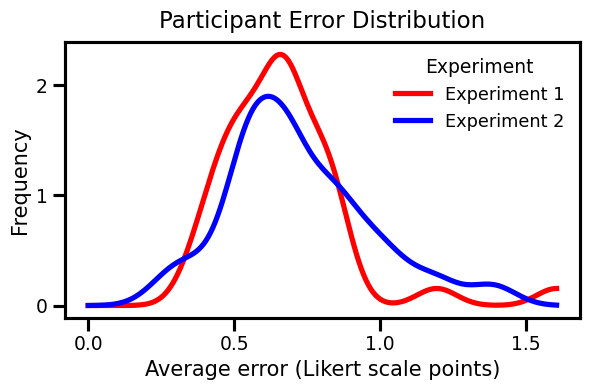

In [ ]:
# =========================================================
# Plottingparticipant error distribution
# =========================================================

bw_multiplier = 0.3
newscale = 1.5  # overall scaling factor for this figure

# --- Global visual scaling (local to this figure) ---
FS = mpl.rcParams['font.size'] * newscale
LW = newscale  # multiplier for line/axis widths

plt.figure(figsize=(6, 4))

ax = plt.gca()

# Thicker axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5 * LW)

# Grid for KDE
grid = np.linspace(0, error_df['avg_error'].max(), 200)

for exp, color, tag in [
    ('img', 'red', "Experiment 1"),
    ('lab', 'blue', "Experiment 2")
]:
    data = error_df.loc[error_df['experiment'] == exp, 'avg_error'].values
    kde = gaussian_kde(data, bw_method=bw_multiplier)
    density = kde(grid)
    ax.plot(
        grid,
        density,
        color=color,
        linewidth=2.5 * LW,
        label=tag
    )

# Labels & title 
ax.set_xlabel('Average error (Likert scale points)', fontsize=FS)
ax.set_ylabel('Frequency', fontsize=FS)
ax.set_title('Participant Error Distribution', fontsize=FS * 1.1, pad=10)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=FS * 0.9,
    width=1.5 * LW,
    length=6 * LW
)


ax.locator_params(axis='x', nbins=4)
ax.locator_params(axis='y', nbins=4)

# Legend
ax.legend(
    title='Experiment',
    fontsize=FS * 0.85,
    title_fontsize=FS * 0.9,
    frameon=False
)

plt.tight_layout()
plt.show()


In [28]:
## printing out average error by image and experiment
print("\nAverage error by image and experiment:")
avg_error_by_img = error_df.groupby(['image_number', 'experiment'])['avg_error'].mean().unstack()
avg_error_by_img

avg_error_by_experiment = error_df.groupby('experiment')['avg_error'].mean()
avg_error_by_experiment


Average error by image and experiment:


experiment
img    0.670678
lab    0.724200
Name: avg_error, dtype: float64

## Performance over time - Figure S2


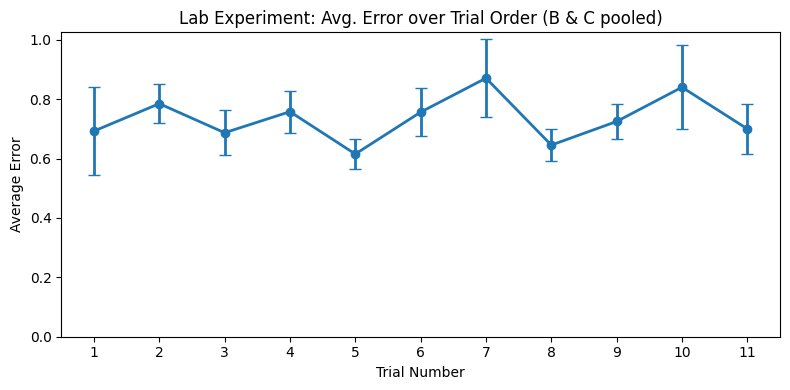

In [30]:


# -- PREP LAB DATA WITH ERRORS & TRIAL NUMBER --

lab = df_vhq_lab_dims.copy()
lab = lab[lab['condition'].isin(['B','C'])].copy()
lab['image_number'] = lab['condition'].map({'B': 2, 'C': 3})

for dim in dimension_labels:
    lab[f'err_{dim}'] = lab.apply(
        lambda row: abs(row[dim] - gt.at[row['image_number'], dim]),
        axis=1
    )

err_cols = [f'err_{d}' for d in dimension_labels]
lab['avg_error'] = lab[err_cols].mean(axis=1)

lab['trial_number'] = lab.apply(
    lambda row: str(row['trial_order']).find(row['condition']) + 1,
    axis=1
)

# -- AGGREGATE OVER TRIALS 1–11 --

agg = lab.groupby('trial_number')['avg_error'].agg(['mean','count','std']).reset_index()
agg['sem'] = agg['std'] / np.sqrt(agg['count'])
all_trials = pd.DataFrame({'trial_number': np.arange(1,12)})
agg = all_trials.merge(agg, on='trial_number', how='left').fillna(0)

# -- PLOT WITH Y=0 BASELINE --

plt.figure(figsize=(8,4))
plt.errorbar(
    agg['trial_number'], agg['mean'],
    yerr=agg['sem'],
    fmt='-o', capsize=4, linewidth=2
)
plt.xticks(np.arange(1,12))
plt.ylim(bottom=0)                      # start y-axis at zero
plt.xlabel('Trial Number')
plt.ylabel('Average Error')
plt.title('Lab Experiment: Avg. Error over Trial Order (B & C pooled)')
plt.tight_layout()
plt.show()

